In [2]:
import numpy as np
import matplotlib.pyplot as plt
import traceback
from collections.abc import Callable

In [3]:
# Ниже приведены функции, проверяющие правильность расчета. 
# Можно их не смотреть, они не относятся к заданию
def check_linear(approx_function):
    _x = np.arange(1, 10)
    _y = [1, 2, 4, 3, 5, 6, 9, 8, 10]
    try:
        _a1, _a0 = approx_function(_x, _y)
        ok = True
        if not np.isclose(_a1, 1.117, atol=1e-2):
            print('Что-то не так с коэффициентом a1')
            ok = False
        if not np.isclose(_a0, -0.25, atol=1e-2):
            print('Что-то не так с коэффициентом a0')
            ok = False
    except TypeError as e:
        ok = False
        if 'ellipsis' in str(e):
            print('Заполните все троеточия в функции, чтобы проверить!')
        else:
            traceback.print_exc()
    if ok:
        print('Всё правильно!')
    

# Аппроксимация методом наименьших квадратов (МНК)

## 1. Линейная аппроксимация

Аппроксимируем экспериментальные данные $\{x_i\}, \{y_i\}, i=\overline{1,n}$ полиномом первой степени:

$$P_1(x) = a_1x + a_0.$$

Выражения для коэффициентов $a_1$ и $a_0$:

---

$$a_1 = \frac{n \sum \limits_{i=1}^n x_iy_i - \left( \sum \limits_{i=1}^n x_i \right) \left( \sum\limits_{i=1}^{n} y_i\right)}{n\sum\limits_{i=1}^n x_i^2 - \left( \sum\limits_{i=1}^n x_i \right)^2},$$

---

$$a_0 = \frac{\left(\sum\limits_{i=1}^n x_i^2\right) \left( \sum\limits_{i=1}^{n} y_i \right) - \left(\sum\limits_{i=1}^n x_i\right)\left(\sum\limits_{i=1}^n x_iy_i\right)}{n \sum\limits_{i=1}^n x_i^2 - \left(\sum\limits_{i=1}^n x_i\right)^2}$$

---

В следующей ячейке рассчитайте все суммы, встречающиеся в коэффициентах $a_1$ и $a_0$.

In [19]:
def linear_approximation(x: list[float], y: list[float]) -> tuple[float, float]:
    """Рассчитывает коэффициенты линейной аппроксимации a_1 и a_0.

    Args:
        x (array_like): Массив дискретных значений {x_i} (list Python или array из numpy).
        y (array_like): Массив дискретных значений {y_i} (list Python или array из numpy).

    Returns:
        (a_0, a_1) (tuple[float, float]): Коэффициенты аппроксимирующего полинома.
    """
    assert len(x) == len(y)  # Проверяем, что длины x и y равны.
    
    # Превращаем массивы x и y в массивы numpy
    x = np.asarray(x)
    y = np.asarray(y)
    
    # TODO Рассчитайте все суммы, встречающиеся в определении коэффициентов a_0 и a_1
    sum_x = ... 
    sum_y = ...
    sum_xy = ...  # Сумма x_i * y_i
    sum_x2 = ...  # Сумма x_i^2
    
    # TODO Используя рассчитанные суммы, рассчитайте a_0 и a_1 согласно формулам, приведенным выше
    n = len(x)
    a_1 = ...
    a_0 = ...
    return a_1, a_0


# Проверяем, правильно ли написана функция. Выполните эту ячейку, чтобы проверить.
check_linear(linear_approximation)

Заполните все троеточия в функции, чтобы проверить!


### Строим график

Сделайте универсальную функцию, которая строит два графика на одной картинке:

1. Дискретные точки, заданные массивами `x_array` и `y_array`.
2. Непрерывный график некоторой функции.

Заполните все троеточия в функции, чтобы проверить!


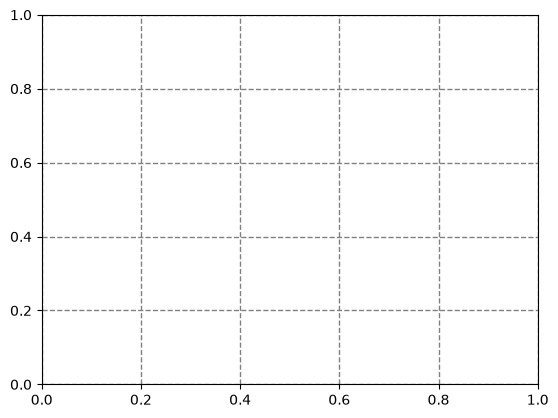

In [ ]:
def plot_discrete_and_cont(
    x_array: list[float], 
    y_array: list[float], 
    function: Callable[[float], float],
    x_start: float | None = None,
    x_stop: float | None = None
) -> None:
    """Универсальная функция для построения дискретных точек и непрерывной 
        функции на одном графике.

    Args:
        x_array (array_like): Массив дискретных x.
        y_array (list[float]): Массив дискретных y.
        function (Callable): Функция, для которой мы строим непрерывный график.
            Эта функция должна принимать один аргумент (x: float) и выдавать 
            значение y (float) в этой точке.
        x_start (float | None, optional): Левая граница отрезка, на котором
            мы строим функцию function. Это опциональный аргумент, по умолчанию он None.
        x_stop (float | None, optional): Правая граница отрезка, на котором
            мы строим функцию function. Это опциональный аргумент, по умолчанию он None.
    """
    # Инициализируем график
    _, ax = plt.subplots()
    # Добавляем сетку на заднем фоне для читаемости
    ax.grid(ls='--', lw=1, color='grey')
    
    # Строим дискретные точки
    # TODO Передайте функции нужные аргументы
    ax.plot(..., ls='None', marker='o')
    
    # Строим непрерывную функцию
    # Проверяем аргументы x_start и x_stop. Если эти значения остались по умолчанию (None),
    # надо заменить их на соответствующие членам массива x_array (используем min() и max())
    if x_start is None:
        x_start = ...  # TODO наименьшее значение массива x_array
    if x_stop is None:
        x_stop = ...  # TODO наибольшее значение массива x_array
    # Создаем массив из 200 точек на отрезке от x_start до x_stop
    x_cont = np.linspace(x_start, x_stop, 200)
    # TODO создайте массив y_cont на основании function и массива x_cont
    # Вы можете вызывать функцию так: yi = function(xi)
    y_cont = ...
    # Строим график
    ax.plot(x_cont, y_cont)
    
# Проверяем
x_array = np.linspace(0, 1, 10)
y_array = np.exp(x_array)
# Определяем непрерывную функцию
def f(x):
    return np.exp(x) + 1
# Строим
try:
    plot_discrete_and_cont(x_array, y_array, function=f)
except TypeError as e:
    if 'ellipsis' in str(e):
        print('Заполните все троеточия в функции, чтобы проверить!')
    else:
        traceback.print_exc()

### Визуализируем наш полином второго порядка

In [6]:
# TODO Придумайте значения x и y для визуализации
x = ...
y = ...

a1, a0 = linear_approximation(x, y)

def approximated(x: float) -> float:
    # TODO Определите эту функцию так, чтобы она выдавала значения аппроксиманта
    # P(x) = a0 + a1 * x.
    return ...

plot_discrete_and_cont(x, y, function=approximated)

NameError: name 'linear_approximation' is not defined